In [98]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
    
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Bagging Sample code

In [99]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier 
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [100]:
X , y = load_iris(return_X_y=True)

DataFrame of x means 2d array of features and y means 1d array of target

In [124]:
df = pd.DataFrame(X)
df

,0,1,2,3,4,5,6,7,8,9
0,0.189421,0.027609,-0.901106,-2.537308,-0.985568,-0.141232,-0.662069,1.053445,-0.141727,0.219517
1,0.077875,0.829368,-0.577396,1.200813,0.927287,-0.100037,-1.219663,-0.046457,-0.352556,1.301771
2,0.665205,-0.005242,1.499883,0.009082,1.536909,-0.616889,-0.493467,0.778687,1.079439,1.276150
3,-0.210598,1.672606,0.861712,-4.450600,-1.845645,-1.650466,-0.426875,1.678965,0.183405,-0.226674
4,-1.654246,0.174077,-0.179159,1.549699,0.514247,-1.321524,-0.410076,-0.556054,-0.613883,0.415190
...,...,...,...,...,...,...,...,...,...,...
9995,0.948049,3.322410,0.362853,0.919665,1.165690,-1.353592,-1.515469,0.264898,0.229696,1.696820
9996,-0.531247,0.920434,-0.807214,-2.104757,0.420008,-0.158972,0.205401,1.324355,-1.291985,0.360029
9997,0.430370,0.539908,0.123437,-1.654617,-1.902608,-0.699859,-0.692058,0.148722,-1.563579,-0.413025
9998,0.524009,-0.111661,0.099974,-2.557900,-0.920346,-0.312583,0.352910,0.935710,1.255230,-0.488603


Store the target (y values) in a new column named target


In [102]:
df['target'] = y

df.sample is used for random sampling. If you want to sample 100 rows from the dataframe then df.sample(100).


In [ ]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)    # 60%
df_val = df.iloc[60:80,:].sample(5)     # 20%
df_test = df.iloc[80:,:].sample(5)      # 20%


In [104]:
df_train

,0,1,2,3,target
123,6.3,2.7,4.9,1.8,2
23,5.1,3.3,1.7,0.5,0
18,5.7,3.8,1.7,0.3,0
58,6.6,2.9,4.6,1.3,1
67,5.8,2.7,4.1,1.0,1
60,5.0,2.0,3.5,1.0,1
101,5.8,2.7,5.1,1.9,2
81,5.5,2.4,3.7,1.0,1
113,5.7,2.5,5.0,2.0,2
121,5.6,2.8,4.9,2.0,2


In [105]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

## Case 1 = Bagging

In [106]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

In [107]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.iloc[:,0:2].values,y.values,clf=clf)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

In [108]:
db_bag1 = DecisionTreeClassifier()

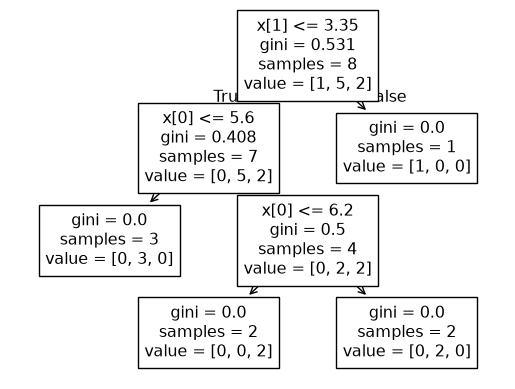

0.4


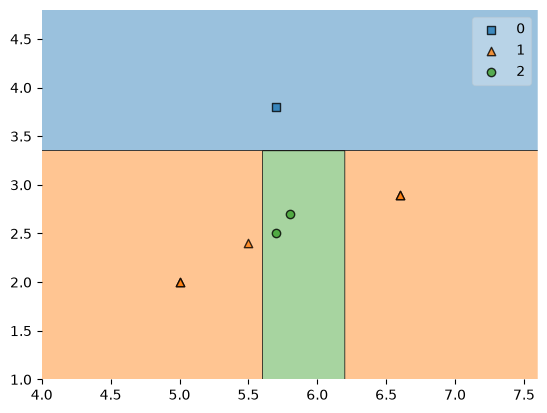

In [109]:
evaluate(db_bag1,X,y)

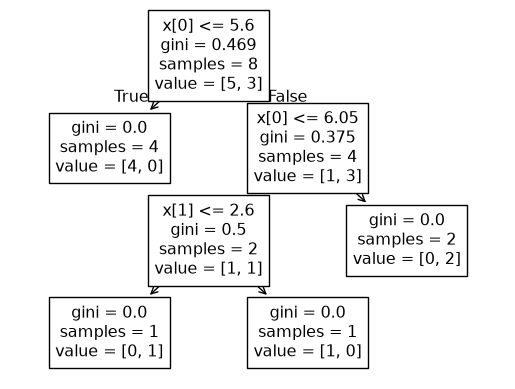

0.6


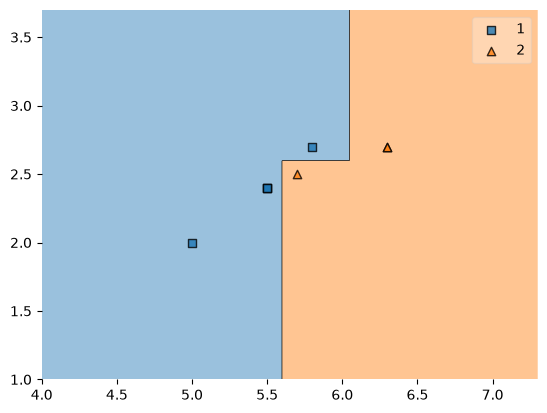

In [110]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
db_bag2 = DecisionTreeClassifier()
evaluate(db_bag2,X,y)

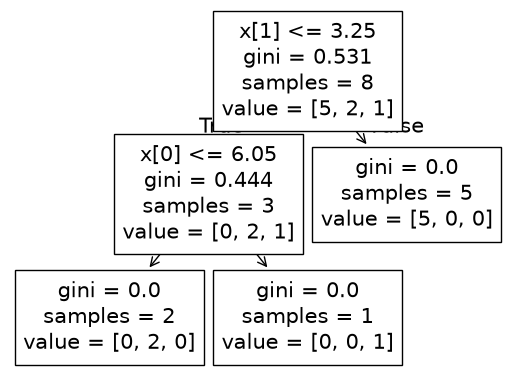

0.8


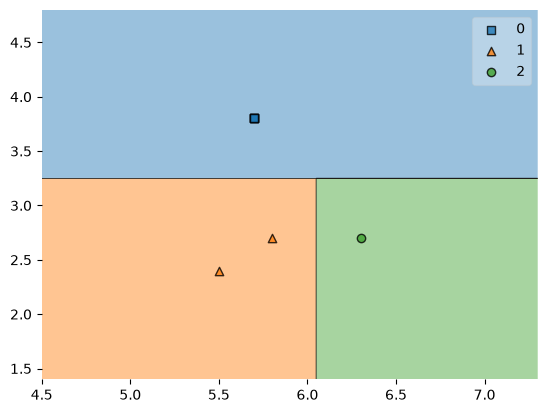

In [111]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
db_bag3 = DecisionTreeClassifier()
evaluate(db_bag3,X,y)

In [112]:
df_test

,0,1,2,3,target
45,4.8,3.0,1.4,0.3,0
89,5.5,2.5,4.0,1.3,1
39,5.1,3.4,1.5,0.2,0
118,7.7,2.6,6.9,2.3,2
96,5.7,2.9,4.2,1.3,1


In [113]:
print("Predictor 1",db_bag1.predict(np.array([6.5,3.0]).reshape(1,2)))
print("Predictor 2",db_bag2.predict(np.array([6.5,3.0]).reshape(1,2)))
print("Predictor 3",db_bag3.predict(np.array([6.5,3.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [2]
Predictor 3 [2]


## Pasting

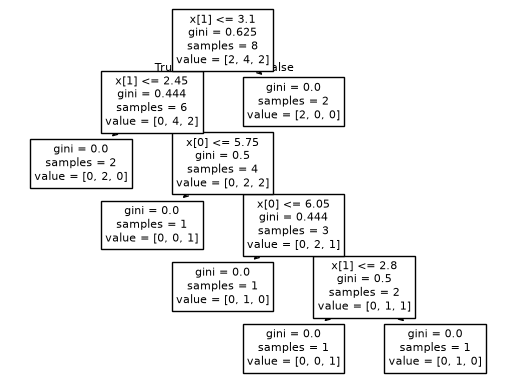

0.4


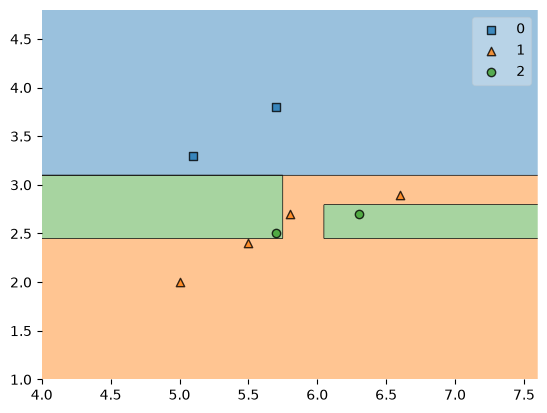

In [114]:
# In case of pasting you do row sampling only but the difference is that
#you do it with replacement as in case of pure bagging you do it without
#replacement
df_bag = df_train.sample(8)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
dp_bag3 = DecisionTreeClassifier()
evaluate(dp_bag3,X,y)

## Random subsapces

In [115]:
#In random subspaces you do column sampling rather than row sampling
df_train.sample(2,replace=True,axis=1)

,1,1
123,2.7,2.7
23,3.3,3.3
18,3.8,3.8
58,2.9,2.9
67,2.7,2.7
60,2.0,2.0
101,2.7,2.7
81,2.4,2.4
113,2.5,2.5
121,2.8,2.8


## Random patches

In [116]:
# In case or random patches you do both column and row sampling
df_train.sample(8,replace=True).sample(2,replace=True,axis=1)

,target,1
60,1,2.0
60,1,2.0
23,0,3.3
58,1,2.9
18,0,3.8
113,2,2.5
101,2,2.7
121,2,2.8


# Sklearn Implementation

In [117]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [118]:
X , y = make_classification(n_samples=10000,n_features=10,n_informative=3)

In [119]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [120]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [121]:
y_pred = dt.predict(X_test)

In [122]:
accuracy_score(y_test,y_pred)

0.9205

In [123]:
bag = BaggingClassifier(
    base_estimator= DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=True,
    random_state=42,
    oob_score=True
)

TypeError: BaggingClassifier.__init__() got an unexpected keyword argument 'base_estimator'

In [ ]:
bag.fit(X_train,y_train)

/opt/conda/lib/python3.10/site-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


BaggingClassifier(base_estimator=DecisionTreeClassifier(), max_samples=0.25,
                  n_estimators=500, oob_score=True, random_state=42)

In [ ]:
y_pred = bag.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.904

In [ ]:
bag.oob_score_

0.9025

In [ ]:
bag = BaggingClassifier(
    estimator= SVC(),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=True,
    random_state=42,
    oob_score=True
)
bag.fit(X_train,y_train)
y_pred = bag.predict(X_test)
accuracy_score(y_test,y_pred)

0.8625

In [ ]:
bag.oob_score_

0.860375

In [ ]:
bag = BaggingClassifier(
    base_estimator= LogisticRegression(),
    n_estimators=500,
    max_samples=0.25,
    bootstrap=True,
    oob_score=True,
    random_state=42
)
bag.fit(X_train,y_train)
y_pred = bag.predict(X_test)
accuracy_score(y_test,y_pred)

/opt/conda/lib/python3.10/site-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


0.504

In [ ]:
bag.oob_score_

0.493875